IMPORTING LIBRARIES

In [19]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

LOADING DATASET

In [20]:
data = fetch_california_housing()


In [21]:
df = pd.DataFrame(data.data,columns = data.feature_names)
df['target'] = data.target

In [22]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


SELECTING FEATURES BY CORR METHOD

In [38]:
df.corr()['target']

MedInc        0.688075
HouseAge      0.105623
AveRooms      0.151948
AveBedrms    -0.046701
Population   -0.024650
AveOccup     -0.023737
Latitude     -0.144160
Longitude    -0.045967
target        1.000000
Name: target, dtype: float64

DATA PREPARATION AS X AND y

In [46]:
X = df.iloc[:,0:8].values
y = df.iloc[:,-1].values

In [47]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [48]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

SPLITTING THE DATASET

In [49]:
X_train,X_test,y_train,y_text = train_test_split(X,y,random_state = 7)


In [50]:
X_train

array([[   1.725     ,   52.        ,    3.38621586, ...,    2.33810143,
          37.88      , -122.26      ],
       [   3.312     ,   17.        ,    6.45175767, ...,    2.61555722,
          33.72      , -116.37      ],
       [   1.2469    ,   33.        ,    4.77325581, ...,    3.36627907,
          35.37      , -119.01      ],
       ...,
       [   4.4821    ,   42.        ,    4.45      , ...,    2.775     ,
          34.24      , -118.26      ],
       [  11.075     ,   38.        ,    7.20467836, ...,    2.39766082,
          33.61      , -117.91      ],
       [   3.4333    ,   27.        ,    3.44308036, ...,    1.62165179,
          37.57      , -122.33      ]], shape=(15480, 8))

MODEL CREATION

In [51]:

model = LinearRegression()

MODEL TRAINING

In [52]:
model.fit(X_train,y_train)

LinearRegression()

MODEL PREDICTION

In [55]:
y_pred = model.predict(X_test)

METRICS

In [56]:
mae = mean_absolute_error(y_text,y_pred)

In [57]:
mae

0.5310081833876922

In [58]:
mse = mean_squared_error(y_text,y_pred)

In [59]:
mse

0.5237529866171119

In [60]:
r2 = r2_score(y_text,y_pred)

In [61]:
r2

0.6070242241118249

#plot

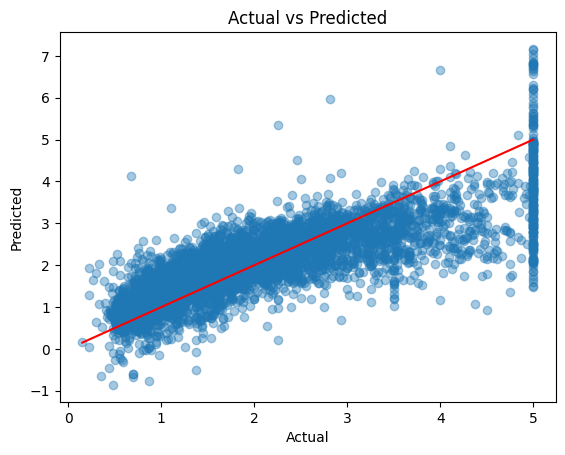

In [62]:
plt.scatter(y_text, y_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([min(y_text), max(y_text)], [min(y_text), max(y_text)], color = "red")
plt.show()